('linear1.weight', Parameter containing:
tensor([[ 0.3027,  0.3848],
        [-0.1110,  0.6179]], requires_grad=True))
('linear1.bias', Parameter containing:
tensor([-0.2949,  0.0859], requires_grad=True))
('linear2.weight', Parameter containing:
tensor([[-0.4346,  0.1077]], requires_grad=True))
('linear2.bias', Parameter containing:
tensor([0.1608], requires_grad=True))
The input is = tensor([0., 1.])
Output y predicted =tensor([0.5014], grad_fn=<SigmoidBackward0>)


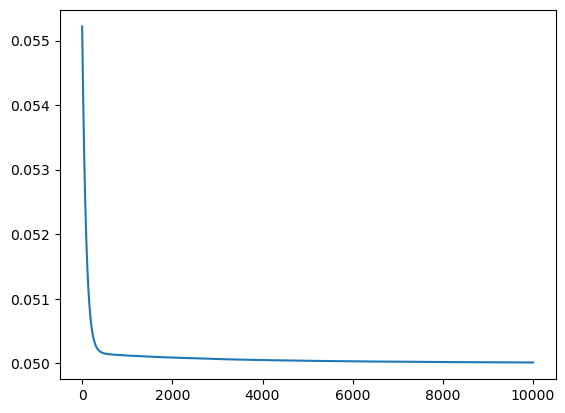

In [7]:
import torch
from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import numpy as np

loss_list = []
torch.manual_seed(42)

X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
Y = torch.tensor([0,1,1,0], dtype=torch.float32)

class XORModel(nn.Module):
    def __init__(self):
        super(XORModel, self).__init__()
        self.linear1 = nn.Linear(2, 2, bias=True)
        self.activation1 = nn.Sigmoid()
        self.linear2 = nn.Linear(2, 1, bias=True)
        self.activation2 = nn.Sigmoid()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)
        x = self.activation2(x)
        return x

class XORDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index].to(device), self.Y[index].to(device)

epochs = 10000
batch_size = 5

full_dataset = XORDataset(X, Y)
train_data_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = XORModel().to(device)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

for epoch in range(epochs):
    model.train(True)
    loss_t = 0.
    for i, data in enumerate(train_data_loader):
        inputs, labels = data # targets == labels
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs.flatten(), labels)
        loss.backward()
        optimizer.step()
        loss_t += loss.item()
    avg_loss = loss_t/(len(train_data_loader) * batch_size)
    loss_list.append(avg_loss)

for param in model.named_parameters():
    print(param)

input_tensor = torch.tensor([0, 1], dtype=torch.float32).to(device)
model.eval()
print("The input is = {}".format(input_tensor))
print("Output y predicted ={}".format(model(input_tensor)))

plt.plot(loss_list)
plt.show()

('linear1.weight', Parameter containing:
tensor([[0.6427, 0.7453],
        [1.8538, 1.9517]], requires_grad=True))
('linear1.bias', Parameter containing:
tensor([-0.7116,  0.2779], requires_grad=True))
('linear2.weight', Parameter containing:
tensor([[-1.2632,  1.4964]], requires_grad=True))
('linear2.bias', Parameter containing:
tensor([-0.1221], requires_grad=True))
The input is = tensor([0., 1.])
Output y predicted =tensor([0.5867], grad_fn=<ReluBackward0>)


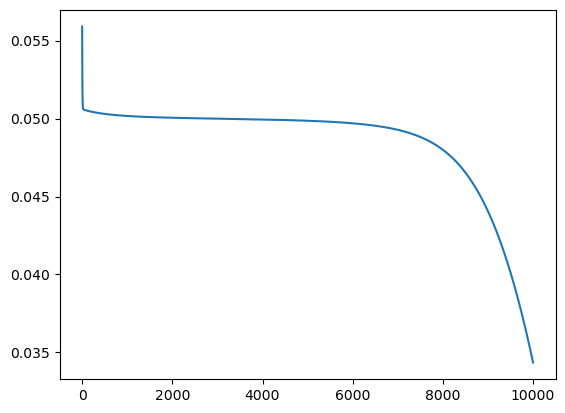

In [8]:
loss_list = []
torch.manual_seed(42)

X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
Y = torch.tensor([0,1,1,0], dtype=torch.float32)

class XORModel(nn.Module):
    def __init__(self):
        super(XORModel, self).__init__()
        self.linear1 = nn.Linear(2, 2, bias=True)
        self.activation1 = nn.Sigmoid()
        self.linear2 = nn.Linear(2, 1, bias=True)
        self.activation2 = nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)
        x = self.activation2(x)
        return x

class XORDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index].to(device), self.Y[index].to(device)

epochs = 10000
batch_size = 5

full_dataset = XORDataset(X, Y)
train_data_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = XORModel().to(device)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

for epoch in range(epochs):
    model.train(True)
    loss_t = 0.
    for i, data in enumerate(train_data_loader):
        inputs, labels = data # targets == labels
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs.flatten(), labels)
        loss.backward()
        optimizer.step()
        loss_t += loss.item()
    avg_loss = loss_t/(len(train_data_loader) * batch_size)
    loss_list.append(avg_loss)

for param in model.named_parameters():
    print(param)

input_tensor = torch.tensor([0, 1], dtype=torch.float32).to(device)
model.eval()
print("The input is = {}".format(input_tensor))
print("Output y predicted ={}".format(model(input_tensor)))

plt.plot(loss_list)
plt.show()

In [9]:
w1 = model.linear1.weight.data
b1 = model.linear1.bias.data
w2 = model.linear2.weight.data
b2 = model.linear2.bias.data

x_input = torch.tensor([0, 1], dtype=torch.float32).to(device)

z1 = torch.matmul(x_input, w1.t()) + b1
a1 = torch.sigmoid(z1)

z2 = torch.matmul(a1, w2.t()) + b2
a2 = torch.sigmoid(z2)

print(f"Manual Calculation Result: {a2.item()}")
print(f"Model Forward Result: {model(x_input).item()}")


Manual Calculation Result: 0.6426050662994385
Model Forward Result: 0.5866888761520386


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Model Definition
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# 2. Parameter Verification
model = MNISTModel()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Learnable Parameters: {total_params}")

# 3. Training Logic (Simplified for brevity)
# Load MNIST, define CrossEntropyLoss and Adam optimizer, and train for 5-10 epochs.

# 4. Confusion Matrix Generation
def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("MNIST Confusion Matrix")
    plt.show()

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

plot_confusion_matrix(model, test_loader)

ModuleNotFoundError: No module named 'torchvision'